In [1]:
#Version Numbers Used to Generate this Pset:
#seaborn=0.11.2
#scipy==1.8.0
#numpy==1.22.2
#matplotlib==3.5.1

import scipy as sp
from pylab import *
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator,FormatStrFormatter,MaxNLocator
import pandas as pd
import seaborn as sns
import collections
from IPython.display import clear_output
import random
import openpyxl
import os 
sns.set_style("ticks")
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, explained_variance_score, r2_score
from sklearn.preprocessing import PolynomialFeatures
import pickle

np.random.seed(1)

mm = 0.1/2.54
os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin/latex'
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['figure.dpi'] = 600
mpl.rcParams['font.size'] = 8
mpl.rcParams['axes.linewidth'] = 0.5
mpl.rcParams['xtick.minor.width'] = 0.4
mpl.rcParams['xtick.major.width'] = 0.5
mpl.rcParams['ytick.minor.width'] = 0.4
mpl.rcParams['ytick.major.width'] = 0.5

plt.rcParams['text.usetex'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

In [2]:
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

my_cmap = ListedColormap(['#00429d', '#4771b2', '#73a2c6', '#a5d5d8', '#ffffe0', '#ffbcaf', '#f4777f', '#cf3759', '#93003a'], name="my_cmap")
my_cmap_r = my_cmap.reversed()
mpl.colormaps.register(cmap=my_cmap)
mpl.colormaps.register(cmap=my_cmap_r)

In [3]:
def getIDX(data, IDX):
    O = np.flatnonzero([x == IDX for x in data['SampleIDX']])
    return np.array(O)

def getAbundance(Processed_sequences,IDX):
    SampleIdx= np.flatnonzero([x == IDX for x in Processed_sequences['SampleIDX']])
    if not any(SampleIdx):
        return
    else:
        O=Processed_sequences.iloc[SampleIdx].values.tolist()[0][1:]
        return O

def getAbundance_fromList(Processed_sequences,IDX_list):
    IDX_list_=np.squeeze([np.where(Processed_sequences['SampleIDX']==x) for x in IDX_list])
    return (np.array(Processed_sequences.iloc[IDX_list_].values)[:,1:]).astype(float)

def Community_PermutateList_simulation(I,S):
    global Metadata,exception_list
    sample_num=100
    O=(3*(I-1)+(S-1))*100+np.arange(0,100)
    return O

def CommunityPermutate(Timepoint, CommunityOrigin, Medium, CoalescenceType):
    global Metadata
    idx = np.where((Metadata['Timepoint'] == Timepoint) &
                   (Metadata['CommunityOrigin'] == CommunityOrigin) &
                   (Metadata['Medium'] == Medium) &
                   (Metadata['CoalescenceType'] == CoalescenceType))[0]
    O = np.concatenate(Metadata['SampleIDX'][idx])
    return O

def CommunityPermutate_withSpeciesPoolsize(Timepoint, CommunityOrigin, Medium, CoalescenceType, species_pool_num):
    global Metadata,exception_list
    idx = (Metadata['Timepoint'] == Timepoint) & \
          (Metadata['CommunityOrigin'] == CommunityOrigin) & \
          (Metadata['Medium'] == Medium) & \
          (Metadata['CoalescenceType'] == CoalescenceType)

    communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
    if CoalescenceType == 'S':
        if species_pool_num == 6:
            idx = idx & (communityIDX <= 9)
        elif species_pool_num == 12:
            idx = idx & ((communityIDX > 9) & (communityIDX <= 18))
        elif species_pool_num == 24:
            idx = idx & ((communityIDX > 18) & (communityIDX <= 30))
    elif CoalescenceType == 'C':
        if species_pool_num == 6:
            idx = idx & (communityIDX <= 14)
        elif species_pool_num == 12:
            idx = idx & ((communityIDX > 14) & (communityIDX <= 41))
        elif species_pool_num == 24:
            idx = idx & ((communityIDX > 41) & (communityIDX <= 47))

    O = Metadata['SampleIDX'][idx]
    O = list(set(O) - set(exception_list))
    return O

def Community_PermutateList(Timepoint, CommunityOrigin, Medium, CoalescenceType, species_pool_num=0, Replicate=-1):
    global Metadata,exception_list
    
    if Replicate==-1:
        idx = (Metadata['Timepoint'] == Timepoint) & \
              (Metadata['CommunityOrigin'] == CommunityOrigin) & \
              (Metadata['Medium'] == Medium) & \
              (Metadata['CoalescenceType'] == CoalescenceType)
    elif Replicate == 1 or Replicate == 2 : 
        idx = (Metadata['Timepoint'] == Timepoint) & \
              (Metadata['CommunityOrigin'] == CommunityOrigin) & \
              (Metadata['Medium'] == Medium) & \
              (Metadata['CoalescenceType'] == CoalescenceType) & \
              (Metadata['Replicate'] == Replicate)
    else : 
        raise ValueError("Invalid input")

    
    if CommunityOrigin=='S':
        communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
        if CoalescenceType == 'S':
            if species_pool_num == 6:
                idx = idx & (communityIDX <= 9)
            elif species_pool_num == 12:
                idx = idx & ((communityIDX > 9) & (communityIDX <= 18))
            elif species_pool_num == 24:
                idx = idx & ((communityIDX > 18) & (communityIDX <= 30))
            elif species_pool_num ==0:
                idx = idx
        elif CoalescenceType == 'C':
            if species_pool_num == 6:
                idx = idx & (communityIDX <= 14)
            elif species_pool_num == 12:
                idx = idx & ((communityIDX > 14) & (communityIDX <= 41))
            elif species_pool_num == 24:
                idx = idx & ((communityIDX > 41) & (communityIDX <= 47))
            elif species_pool_num ==0:
                idx = idx
    elif CommunityOrigin=='N':
        communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
        
    O = Metadata['SampleIDX'][idx]
    O = list(set(O) - set(exception_list))
    return O

def getCommunities(Communities_data,IDX_list):
    IDX_list_=np.squeeze([np.where(Communities_data['SampleIDX']==x) for x in IDX_list])
    return (Communities_data.iloc[IDX_list_])

def getCoalescence(Coalescence_data,IDX_list):
    IDX_list_=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])#IDX_list_
    return (Coalescence_data.iloc[IDX_list_])

Coalescence_data_synthetic_path ="../../Analyzed/processed_CoalescenceEvent_synthetic.xlsx"
Communities_data_synthetic_path ="../../Analyzed/processed_Communities_synthetic.xlsx"
Coalescence_data_natural_path ="../../Analyzed/processed_CoalescenceEvent_natural.xlsx"
Communities_data_natural_path ="../../Analyzed/processed_Communities_natural.xlsx"
Coalescence_recipe_path="../../Postprocessed/CoalescenceRecipe.xlsx"
Meta_data_path="../../Postprocessed/Metadata.xlsx"
Processed_sequences_synthetic_path="../../Postprocessed/processed_Sequences_synthetic.xlsx"
Processed_sequences_natural_path="../../Postprocessed/processed_Sequences_natural.xlsx"
Coalescence_data_sim_path="../../Analyzed/processed_CoalescenceEvent_simulation_uniform.xlsx"
#Communities_data_sim_path="Analyzed/processed_Communities_simulation_uniform.xlsx"

Coalescence_data=pd.concat([pd.read_excel(Coalescence_data_synthetic_path),pd.read_excel(Coalescence_data_natural_path)])
Communities_data=pd.concat([pd.read_excel(Communities_data_synthetic_path),pd.read_excel(Communities_data_natural_path)])
Coalescence_data_sim=pd.read_excel(Coalescence_data_sim_path)
#Communities_data_sim=pd.read_excel(Communities_data_sim_path)

Coalescence_recipe=pd.read_excel(Coalescence_recipe_path,sheet_name=0)
Coalescence_natural_recipe=pd.read_excel(Coalescence_recipe_path,sheet_name=1)
Metadata=pd.read_excel(Meta_data_path)
Processed_sequences_synthetic=pd.read_excel(Processed_sequences_synthetic_path)
Processed_sequences_natural=pd.read_excel(Processed_sequences_natural_path)

exception_list=['P4-02','P4-03','P4-23','P4-24','P7-97', 'P8-12']+['P8-91'] + ['P5-73', 'P5-69','P5-64','P5-61','P5-59', 'P5-56'] + ['P5-47', 'P5-50'] + ['P5-39', 'P5-87', 'P5-54', 'P6-02', 'P6-47', 'P6-74', 'P6-57']
#'P4-02','P4-03','P4-23','P4-24','P7-97', 'P8-12' : These cases are for no reads in coalescence result
# 'P8-91' : no file
#['P5-73', 'P5-69','P5-64','P5-61','P5-59', 'P5-56'] : MN E7 is missing
# 'P6-67' : is too low reads( 500)
# 'P5-47', 'P5-50' : MN24 CC, too much unwanted ASVs(maybe due to wrong labeling)
# ['P5-39', 'P5-87', 'P5-54', 'P6-02', 'P6-47', 'P6-74', 'P6-57'] : ASV not in sub 2> 0.3

I = [0.33, 0.66, 0.99]
species_pools = [6, 12, 24]
sample_num=100
Syn_Simulation_IDX = {
    "I1_S1": Community_PermutateList_simulation(1,1),
    "I1_S2": Community_PermutateList_simulation(1,2),
    "I1_S3": Community_PermutateList_simulation(1,3),
    "I2_S1": Community_PermutateList_simulation(2,1),
    "I2_S2": Community_PermutateList_simulation(2,2),
    "I2_S3": Community_PermutateList_simulation(2,3),
    "I3_S1": Community_PermutateList_simulation(3,1),
    "I3_S2": Community_PermutateList_simulation(3,2),
    "I3_S3": Community_PermutateList_simulation(3,3),
}
mediums_pools = ["LN", "MN", "HN"]
species_pools = [6, 12, 24]
Syn_Coal_IDX = {
    "LN_6": Community_PermutateList("F", "S", "L", "C", 6),
    "LN_12": Community_PermutateList("F", "S", "L", "C", 12),
    "LN_24": Community_PermutateList("F", "S", "L", "C", 24),
    "MN_6": Community_PermutateList("F", "S", "M", "C", 6),
    "MN_12": Community_PermutateList("F", "S", "M", "C", 12),
    "MN_24": Community_PermutateList("F", "S", "M", "C", 24),
    "HN_6": Community_PermutateList("F", "S", "H", "C", 6),
    "HN_12": Community_PermutateList("F", "S", "H", "C", 12),
    "HN_24": Community_PermutateList("F", "S", "H", "C", 24)
}
Syn_Sub_IDX = {
    "LN_6": Community_PermutateList("F", "S", "L", "S", 6),
    "LN_12": Community_PermutateList("F", "S", "L", "S", 12),
    "LN_24": Community_PermutateList("F", "S", "L", "S", 24),
    "MN_6": Community_PermutateList("F", "S", "M", "S", 6),
    "MN_12": Community_PermutateList("F", "S", "M", "S", 12),
    "MN_24": Community_PermutateList("F", "S", "M", "S", 24),
    "HN_6": Community_PermutateList("F", "S", "H", "S", 6),
    "HN_12": Community_PermutateList("F", "S", "H", "S", 12),
    "HN_24": Community_PermutateList("F", "S", "H", "S", 24)
}
Nat_Coal_IDX = {
    "LN": Community_PermutateList("F", "N", "L", "C"),
    "MN": Community_PermutateList("F", "N", "M", "C"),
    "HN": Community_PermutateList("F", "N", "H", "C")
}
Nat_Sub_IDX = {
    "LN": Community_PermutateList("F", "N", "L", "S"),
    "MN": Community_PermutateList("F", "N", "M", "S"),
    "HN": Community_PermutateList("F", "N", "H", "S")
}




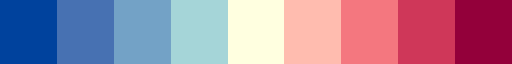

In [4]:
my_cmap



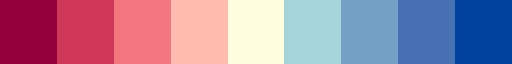

In [5]:
my_cmap_r


In [6]:
from InitializeSpeciesPool import *
from LV import *
from VariousMetrics import *





########################################################
########################################################
# Fig 1-1
########################################################
########################################################

##~~~~~~~~~~~~~~ This figure is cartoon ~~~~~~~~~~~~~~##

In [7]:
def uniform_distribution(u,o):
    return (2*u+2*o)*np.random.random()-o

def input_distribution():
    k=0.8
    return np.random.exponential(k)

def InitializeCommunityPool(N, num_C, num_S, I,g,k, save_path="Data/test"):
    
    CommunitiesLibrary=np.zeros([num_C, N])
    for i in range(num_C):
        #CommunitiesLibrary[i,random.sample(list(np.arange(N)), num_S)]=1
        CommunitiesLibrary[i,np.arange(num_S*i,num_S*(i+1))]=1
    df1=pd.DataFrame(CommunitiesLibrary)
    with pd.ExcelWriter(save_path+'/commuityLibrary.xlsx') as writer:  
        df1.to_excel(writer,sheet_name='Sheet1')
    return CommunitiesLibrary

In [8]:
session_name="Data/OneVar_U_dependency"
if not os.path.exists(session_name):

   # Create a new directory because it does not exist
   os.makedirs(session_name)
   print("The new directory is created!")


###################
######################################
#########################################################

N_simul=50
S=12
u_list=np.arange(0,1.5,0.1)
o=0
t=[0,5000]
num_C=2
num_S=12
N=num_C*num_S
threshold=1e-3

###################
######################################
#########################################################
Intention_to_reset=False
if Intention_to_reset or not os.path.isfile(session_name+'/Data_Assymetricity.xlsx'):
    Data_Assymetricity=np.zeros((len(u_list),N_simul))
    for i,u in enumerate(u_list):
        for itt in range(N_simul):
            ###########
            np.random.seed(itt)
            f_interaction=lambda : uniform_distribution(u,o)

            I,g,k= InitializeSpeceiesPool(N, f_interaction, f_g = lambda :np.ones(1),f_k = lambda :np.ones(1), is_diagonal_one=True, save_path=session_name)

            CommunitiesLibrary= InitializeCommunityPool(N, num_C, num_S, I,g,k, save_path=session_name)

            y=np.random.rand(N)*0.1
            y1=run_lotka_volterra(y, t, CommunitiesLibrary[0,:], I, g, k)
            y2=run_lotka_volterra(y, t, CommunitiesLibrary[1,:], I, g, k)

            y1[y1<threshold]=0
            y2[y2<threshold]=0
            y3=np.array(y1+y2)
            survived=y3>threshold
            y3=run_lotka_volterra(y3, t, survived, I, g, k)
            y3[y3<threshold]=0
            Similarity_to1 =(SimilarityTo1(y3/sum(y3), y1/sum(y1), y2/sum(y2), threshold, lambda x,y,z : SimilarityBC(x,y,z)))

            Assimilarity_BC=abs(2* Similarity_to1-1)
            Data_Assymetricity[i,itt]=Assimilarity_BC
            #########

    df1=pd.DataFrame(Data_Assymetricity)
    with pd.ExcelWriter(session_name+'/Data_Assymetricity.xlsx') as writer:  
        df1.to_excel(writer,sheet_name='Sheet1')

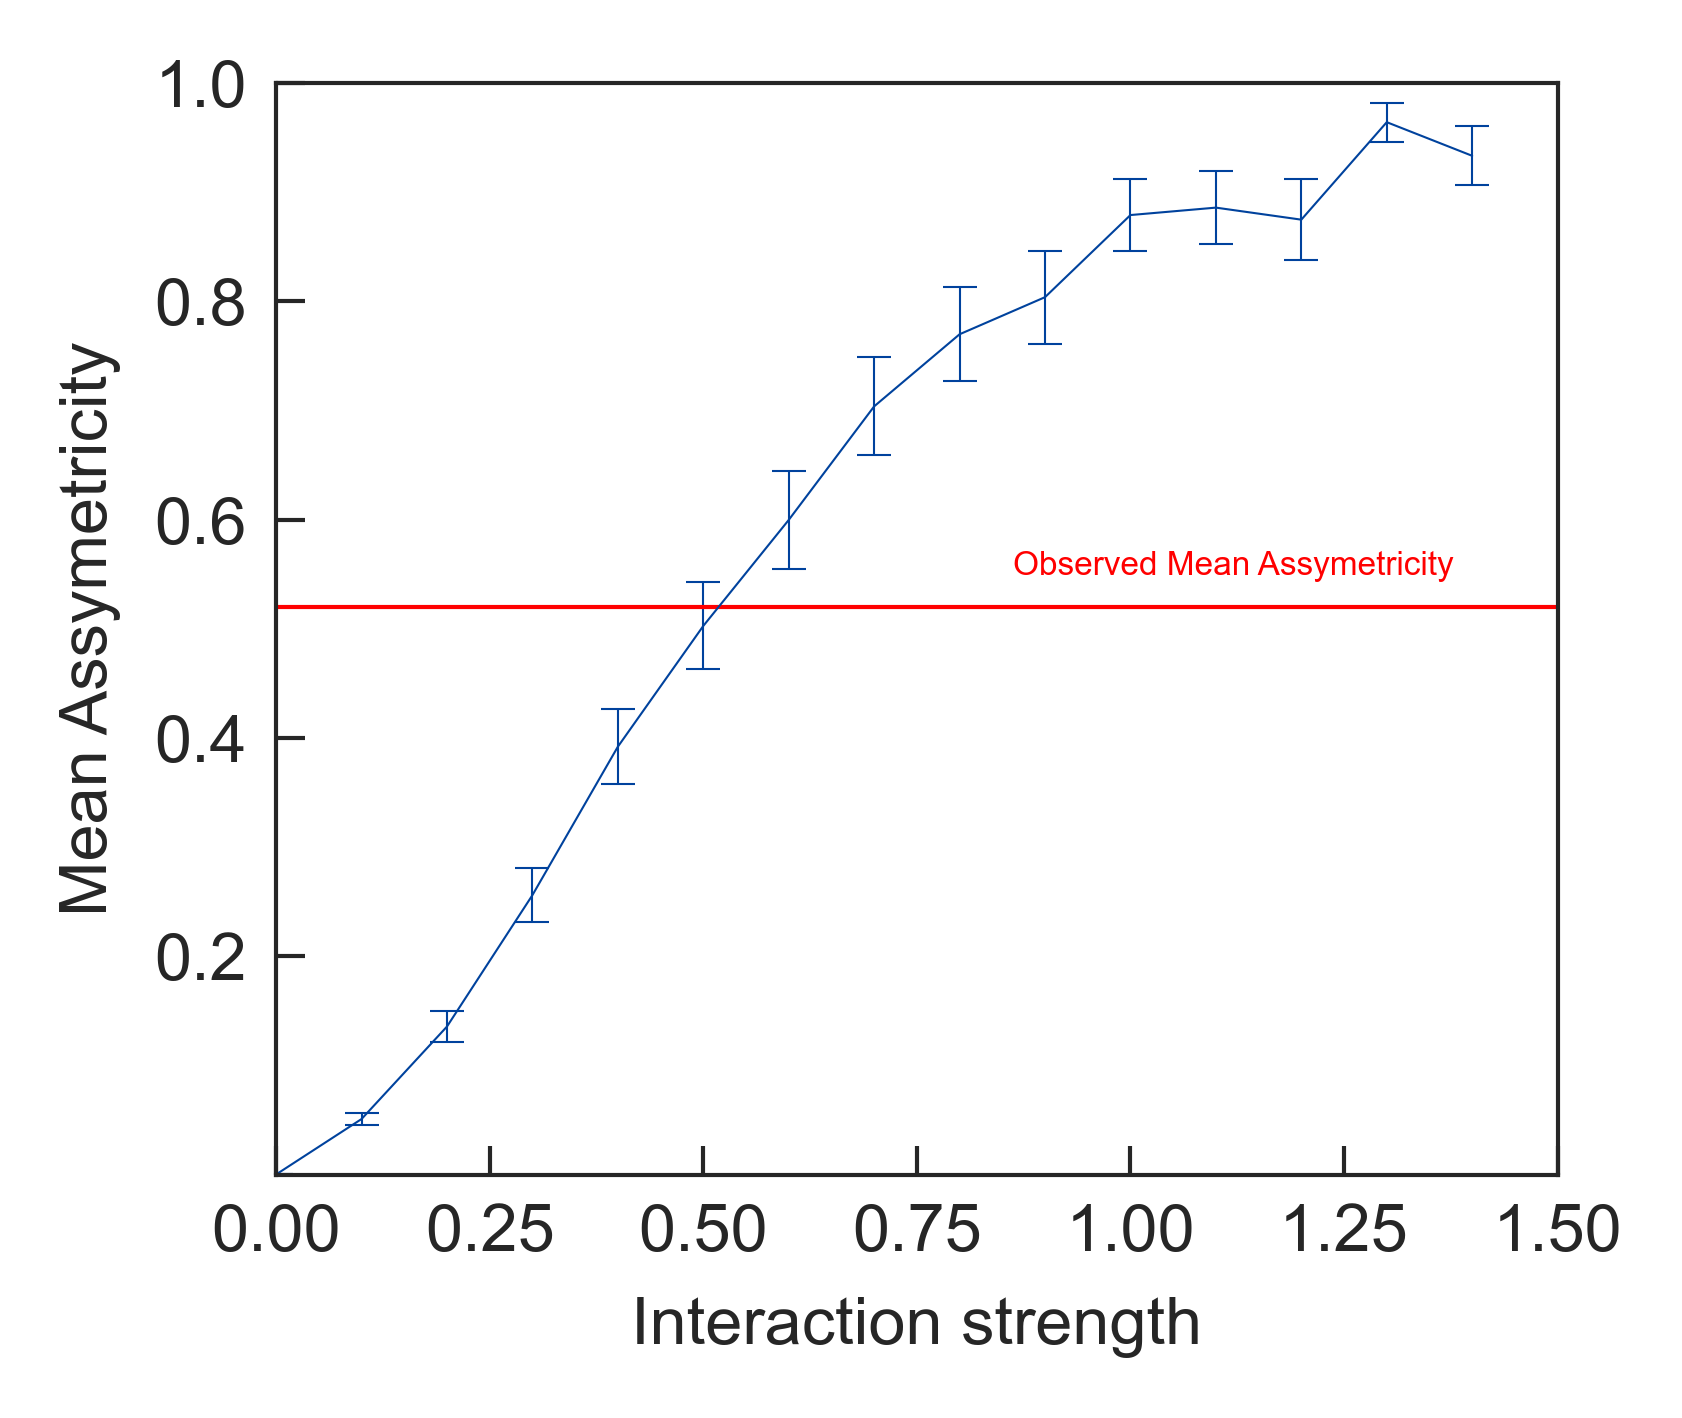

In [9]:
df = pd.read_excel(session_name+'/Data_Assymetricity.xlsx')

df = df.values[0:,1:]


f, ax = plt.subplots(1, figsize=(70*mm,60*mm), facecolor='w', edgecolor='k')

x=u_list
y=np.mean(df,1)
yerr=np.std(df,1)/np.sqrt(df.shape[1])
plt.errorbar(x,y,yerr, linewidth=0.25, color=my_cmap(0), elinewidth=.25, capsize=2,capthick=.25)
#plt.scatter(df.values, cmap='gist_gray', interpolation='nearest')

# Add a colorbar to show the scale of the heatmap

# Add labels and title

# Display the grid
#plt.grid(False)

Obs=0.52
plt.axhline(y=Obs, color='red', linewidth=0.5)

# Add text "Observed" above the line
plt.text(1.12, Obs+0.03, "Observed Mean Assymetricity", color='red', fontsize=4, ha='center')
plt.xlabel('Interaction strength')
plt.ylabel('Mean Assymetricity')
plt.ylim(3*1e-4, 1)
plt.xlim(0, 1.5)

# Show the plot
plt.show()
# Display the plot
plt.show()
f.savefig('Figure/Fig_2-2_OnveVar_U_dependency_errorbar.svg', bbox_inches='tight')


In [10]:
def adjacent_values(vals, q1, q3):
    upper_adjacent_value = q3 + (q3 - q1) * 1.5
    upper_adjacent_value = np.clip(upper_adjacent_value, q3, vals[-1])

    lower_adjacent_value = q1 - (q3 - q1) * 1.5
    lower_adjacent_value = np.clip(lower_adjacent_value, vals[0], q1)
    return lower_adjacent_value, upper_adjacent_value

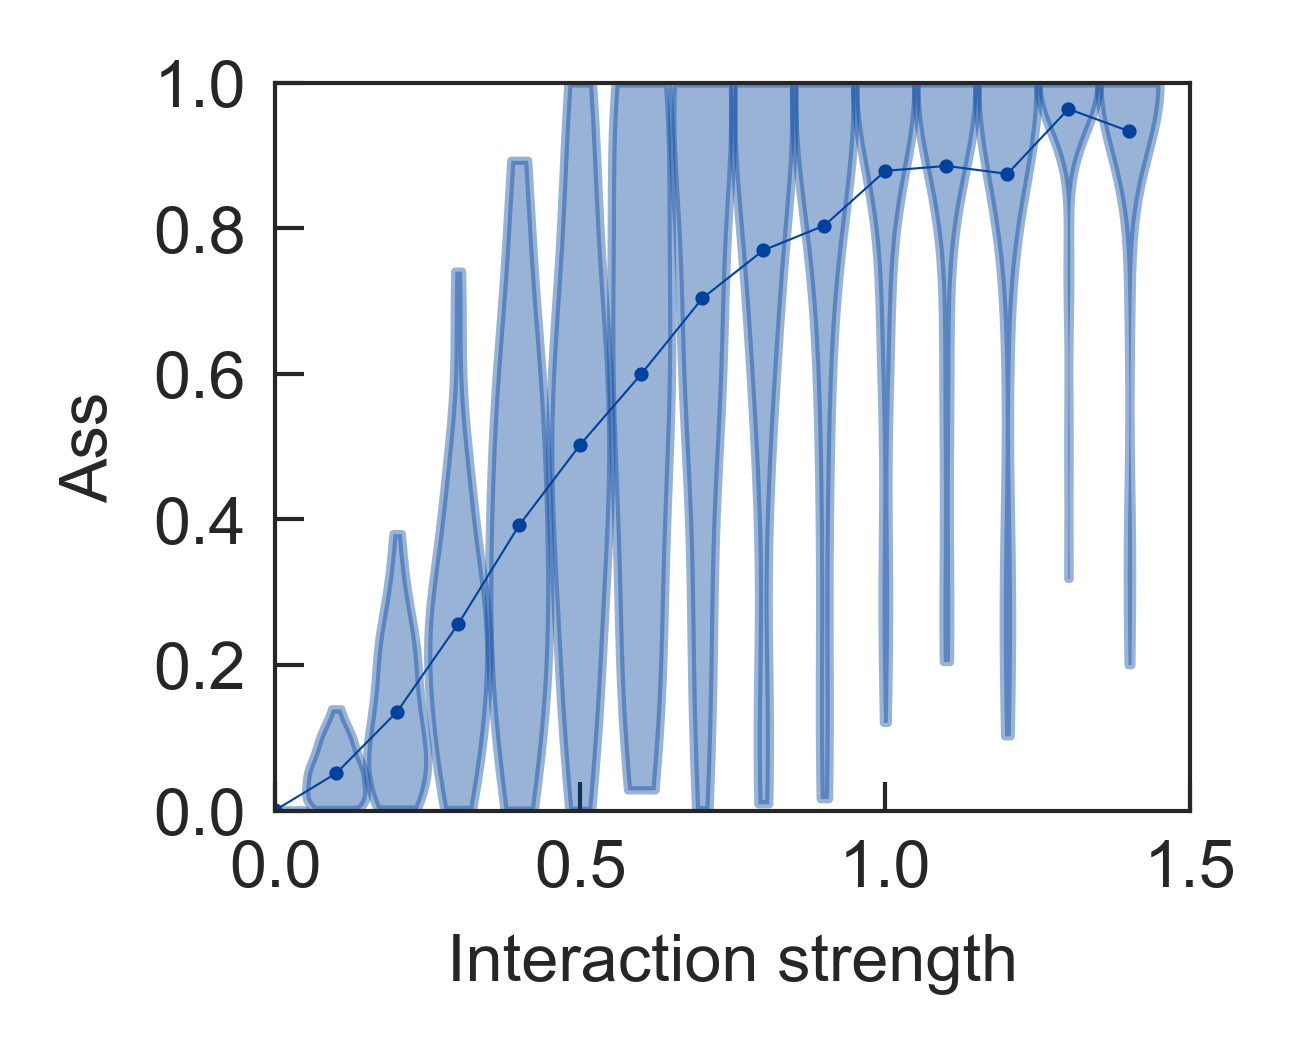

In [11]:
df = pd.read_excel(session_name+'/Data_Assymetricity.xlsx')

df = df.values[0:,1:]
df = np.transpose(df)

f, ax = plt.subplots(1, figsize=(50*mm,40*mm), facecolor='w', edgecolor='k')

x=u_list
y=np.mean(df,0)
yerr=np.std(df,1)
plt.scatter(u_list, np.mean(df,0), s=0.5, color= my_cmap(0))
plt.plot(u_list, np.mean(df,0), linewidth=0.25, color=my_cmap(0))
parts = plt.violinplot(df, u_list,  widths=0.1, showmeans=False,  showextrema=False, showmedians=False,bw_method=.5)


for pc in parts['bodies']:
    pc.set_facecolor(my_cmap(0))
    pc.set_edgecolor(my_cmap(0))
    pc.set_alpha(0.4)

#plt.scatter(df.values, cmap='gist_gray', interpolation='nearest')

# Add a colorbar to show the scale of the heatmap

# Add labels and title

# Display the grid
#plt.grid(False)
plt.xlabel('Interaction strength')
plt.ylabel('Ass')
plt.xlim(0, 1.5)
plt.ylim(0, 1)

# Display the plot
plt.show()
f.savefig('Figure/Fig_2-2_OnveVar_U_dependency_violin.svg', bbox_inches='tight')


In [12]:
session_name="Data/U_0.5"
if not os.path.exists(session_name):

   # Create a new directory because it does not exist
   os.makedirs(session_name)
   print("The new directory is created!")


###################
######################################
#########################################################

N_simul=200
S=12
u_list=[0.5]
o=0
t=[0,5000]
num_C=2
num_S=12
N=num_C*num_S
threshold=1e-3

###################
######################################
#########################################################
Intention_to_reset=False
if Intention_to_reset or not os.path.isfile(session_name+'/Data_Assymetricity.xlsx'):
    Data_Assymetricity=np.zeros((len(u_list),N_simul))
    Data_Assymetricity_null=np.zeros((len(u_list),N_simul))

    for i,u in enumerate(u_list):
        for itt in range(N_simul):
            ###########
            np.random.seed(itt)
            f_interaction=lambda : uniform_distribution(u,o)

            I,g,k= InitializeSpeceiesPool(N, f_interaction, f_g = lambda :np.ones(1),f_k = lambda :np.ones(1), is_diagonal_one=True, save_path=session_name)

            CommunitiesLibrary= InitializeCommunityPool(N, num_C, num_S, I,g,k, save_path=session_name)

            y=np.random.rand(N)*0.1
            y1=run_lotka_volterra(y, t, CommunitiesLibrary[0,:], I, g, k)
            y2=run_lotka_volterra(y, t, CommunitiesLibrary[1,:], I, g, k)

            y1[y1<threshold]=0
            y2[y2<threshold]=0
            y3=np.array(y1+y2)
            survived=y3>threshold
            y3=run_lotka_volterra(y3, t, survived, I, g, k)
            y3[y3<threshold]=0
            Similarity_to1 =(SimilarityTo1(y3/sum(y3), y1/sum(y1), y2/sum(y2), threshold, lambda x,y,z : SimilarityBC(x,y,z)))

            Assimilarity_BC=abs(2* Similarity_to1-1)
            Data_Assymetricity[i,itt]=Assimilarity_BC
            #########
            
            for _ in range(1):
                c_mix=y3
                c_1=y1
                c_2=y2
                species_num=num_S*2
                mix_label=(np.random.rand(species_num)>0.5).astype(int)
                moc_c1=(mix_label)*c_1+(1-mix_label)*c_2
                moc_c2=(1-mix_label)*c_1+(mix_label)*c_2
                moc_c1=moc_c1/(np.sum(moc_c1)+1e-9)
                moc_c2=moc_c2/(np.sum(moc_c2)+1e-9)

                F1=np.sum(np.minimum(moc_c1,c_mix))
                F2=np.sum(np.minimum(moc_c2,c_mix))

                similarity=(F1)/(F1+F2)
                Assimilarity_BC_null=(abs(2*similarity-1))
            Data_Assymetricity_null[i,itt]=Assimilarity_BC_null

    df1=pd.DataFrame(Data_Assymetricity)
    df2=pd.DataFrame(Data_Assymetricity_null)
    with pd.ExcelWriter(session_name+'/Data_Assymetricity.xlsx') as writer:  
        df1.to_excel(writer,sheet_name='Sheet1')
        df2.to_excel(writer,sheet_name='Sheet2')

In [13]:
df = pd.read_excel(session_name+'/Data_Assymetricity.xlsx',sheet_name='Sheet1')
df = df.values[0:,1:]
df1 = np.transpose(df)

df = pd.read_excel(session_name+'/Data_Assymetricity.xlsx',sheet_name='Sheet2')
df = df.values[0:,1:]
df2 = np.transpose(df)

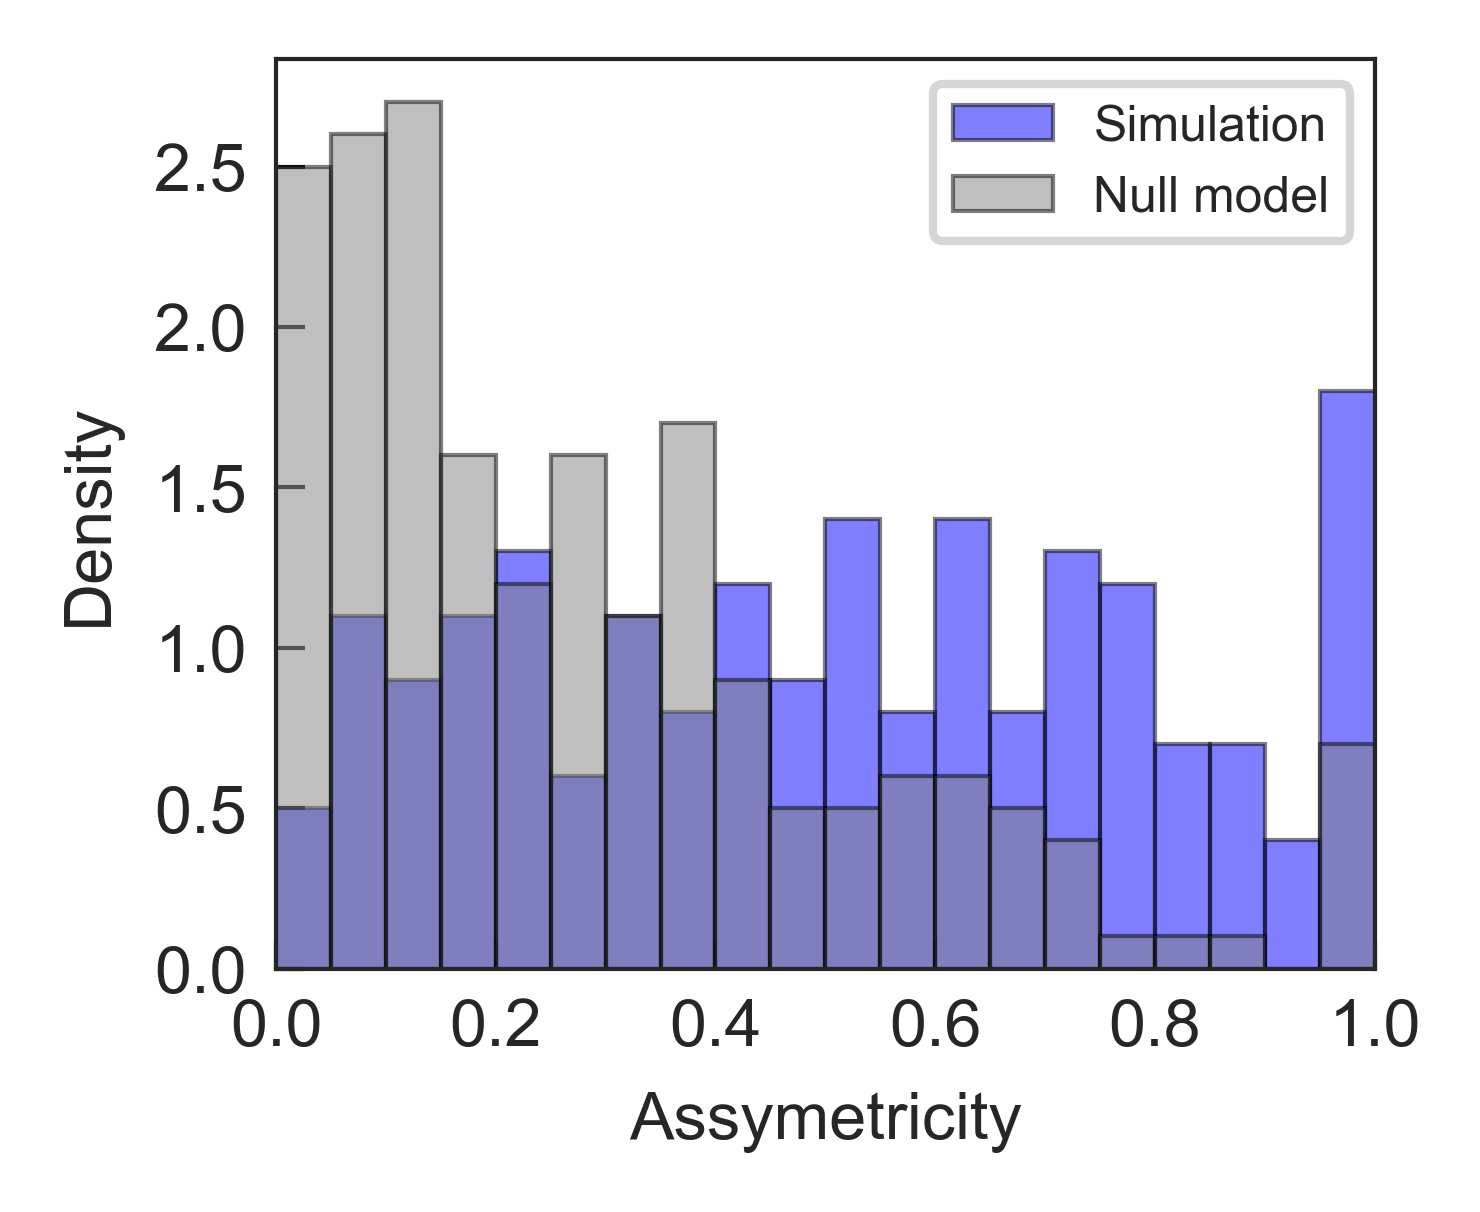

In [14]:
########################################################
########################################################
# Fig 1-5-2
########################################################
########################################################

## This figure shows the distribution of "Assymetricity"

## Coal Figure 2. Plot every variable - swarm&box

typeofplot='swarmpoint' 

f, ax = plt.subplots(1, figsize=(60*mm,50*mm), facecolor='w', edgecolor='k')

    #plt.scatter(data, y_positions, marker='o', color='r', s=10, alpha=0.5, label="Data Points")
plt.hist(df1, bins=np.arange(0,1.05,0.05), density=True, alpha=0.5, color="blue", label="Fraction", edgecolor='black', linewidth=0.5)

    #sns.kdeplot(data, shade=True,bw_adjust=.6)
plt.hist(df2, bins=np.arange(0,1.05,0.05), density=True, alpha=0.5, color='grey',label="Fraction", edgecolor='black', linewidth=0.5)
    
    
#plt.title("KDE with Floating Data Points")
plt.legend(['Simulation', 'Null model'],prop={'size': 6})
plt.xlabel("Assymetricity")
plt.ylabel("Density")
plt.xlim(0, 1)

f.savefig('Figure/Fig_2-5_DistributionOfAssymetricity_simulation_versionHisto.svg', bbox_inches='tight')



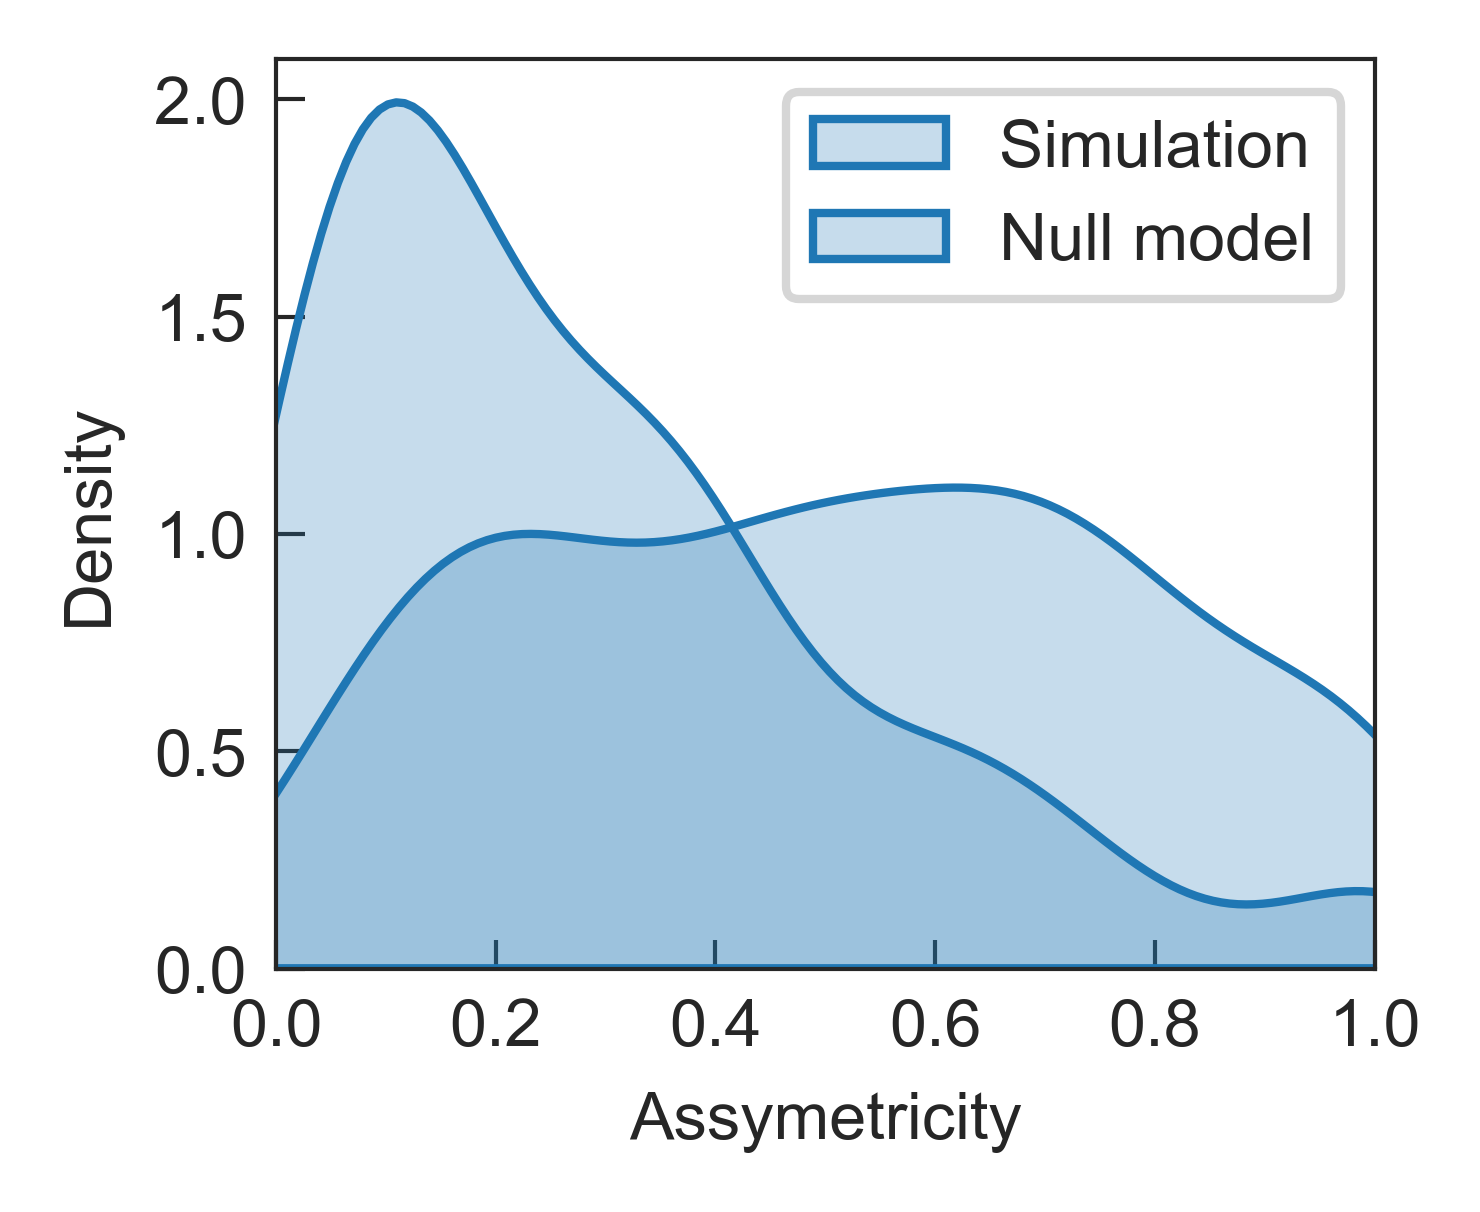

In [15]:
f, ax = plt.subplots(1, figsize=(60*mm,50*mm),facecolor='w', edgecolor='k')

sns.kdeplot(df1, fill=True, bw_adjust=1, color=my_cmap(0))
sns.kdeplot(df2, fill=True, bw_adjust=1, linewidth=1.0, color='grey')

#plt.title("KDE with Floating Data Points")
plt.legend(['Simulation', 'Null model'])
plt.xlabel("Assymetricity")
plt.ylabel("Density")
plt.xlim(0, 1)


f.savefig('Figure/Fig_2-5_DistributionOfAssymetricity_simulation_versionKDE.svg', bbox_inches='tight')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


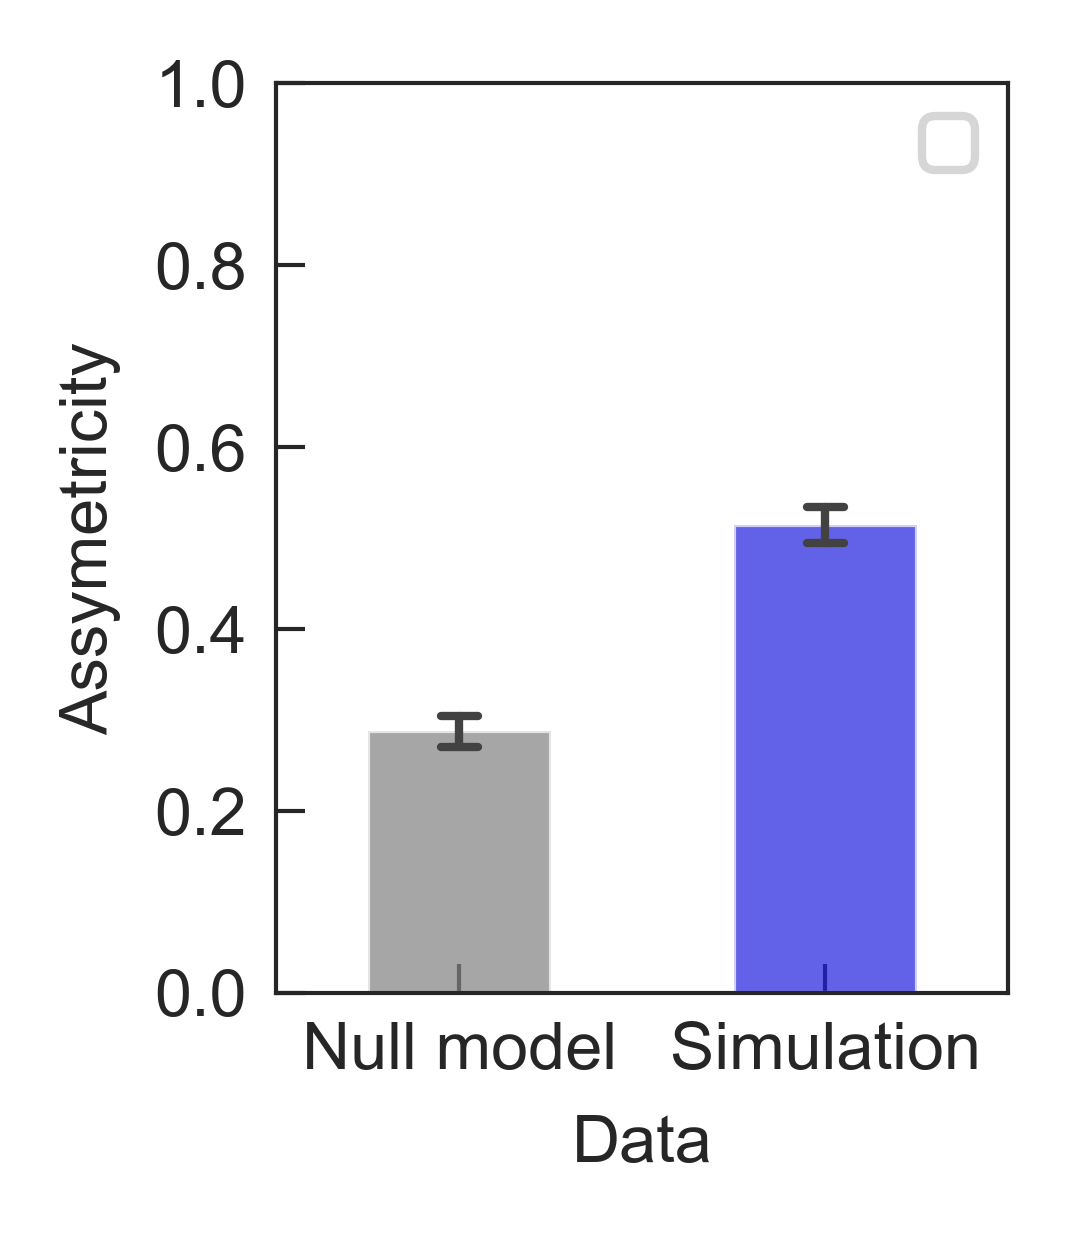

In [16]:
    data1=np.squeeze(df2)
    data2=np.squeeze(df1)

    combined_data = np.squeeze(np.concatenate([data1, data2]))
    labels = ['Null model'] * len(data1) + ['Simulation'] * len(data2)
    df = pd.DataFrame({'Value': combined_data, 'Data': labels})

    # Convert the data into a DataFrame
    f, ax = plt.subplots(1, figsize=(40*mm,50*mm),facecolor='w', edgecolor='k')
    sns.barplot(x='Data', y='Value', data=df, errorbar=('se'), order=['Null model', 'Simulation'], width=0.5,  linewidth=.5, capsize=.1, errwidth=1, alpha=0.7, palette = {"Null model": "grey", "Simulation": "blue"})
    plt.ylim(0, 1)
    plt.ylabel('Assymetricity')
    plt.legend()
    plt.show()

    f.savefig('Figure/Fig_2-5_DistributionOfAssymetiricty_simulation_boxplot.svg',bbox_inches='tight')


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


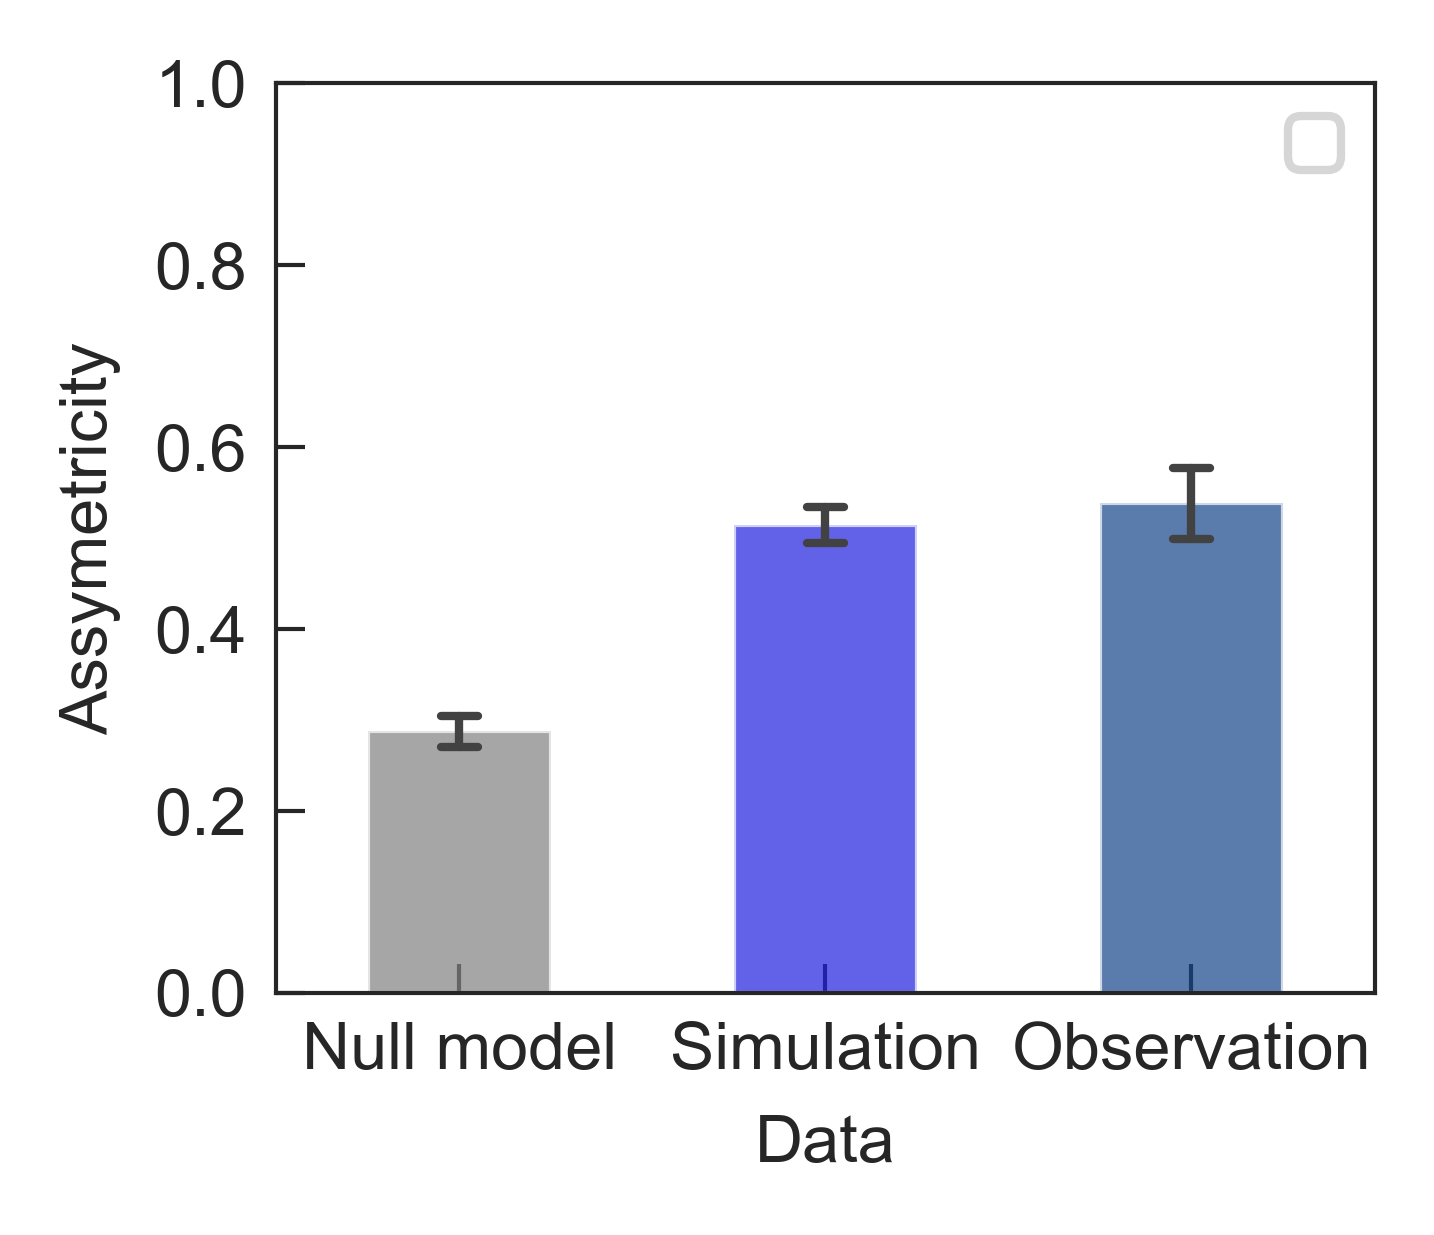

In [17]:

if True:
    Variable2plot_list=['ASVs_notinsub1_3',
               'ASVs_notinsub2_3', 'ASVs_overlap1_3', 'ASVs_overlap2_3',
                'Additivity3_5', 'Assymetricity_BC_5',
               'Assymetricity_J_5', 'Assymetricity_JS_5', 'Assymetricity1_5',
               'Assymetricity2_5', 'ASVs_notinsub1_5', 'ASVs_notinsub2_5',
               'ASVs_overlap1_5', 'ASVs_overlap2_5']


    type_name='MN_12'
    Variable2plot=Variable2plot='SimilarityTo1_BC_5'

    IDX_list = Syn_Coal_IDX[type_name]
    data = getCoalescence(Coalescence_data,IDX_list)
    data =  data['Assymetricity_BC_5']
    
    data1=np.squeeze(df2)
    data2=np.squeeze(df1)
    data3=(data.values).T

    combined_data = np.squeeze(np.concatenate([data1, data2, data3]))
    labels = ['Null model'] * len(data1) + ['Simulation'] * len(data2)+ ['Observation']* len(data3)
    df = pd.DataFrame({'Value': combined_data, 'Data': labels})

    # Convert the data into a DataFrame
    f, ax = plt.subplots(1, figsize=(60*mm,50*mm),facecolor='w', edgecolor='k')
    sns.barplot(x='Data', y='Value', data=df, errorbar=('se'), order=['Null model', 'Simulation', 'Observation'], width=0.5,  linewidth=.5, capsize=.1, errwidth=1, alpha=0.7, palette = {"Null model": "grey", 'Observation': my_cmap(0), "Simulation": "blue"})
    plt.ylim(0, 1)
    plt.ylabel('Assymetricity')
    plt.legend()
    plt.show()

    f.savefig('Figure/Fig_2-5_DistributionOfAssymetiricty_simulation_withObservation_boxplot.svg',bbox_inches='tight')


In [18]:
########################################################
########################################################
# Fig 1-5-2
########################################################
########################################################

from scipy.stats import ttest_ind

# Perform the t-test
x=abs(data2)
y=abs(data3)
t_stat, p_value = ttest_ind(x,y,equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.100f}")

T-statistic: -0.5422
P-value: 0.5893605861226777209438409954600501805543899536132812500000000000000000000000000000000000000000000000


In [ ]:
########################################################
########################################################
# Fig 1-5-2
########################################################
########################################################

## This figure shows the distribution of "Assymetricity"

## Coal Figure 2. Plot every variable - swarm&box

typeofplot='swarmpoint' # choose among 'swarmbox', 'swarmpoint'
# Variable2plot_list=['Threshold_num',
#        'Threshold_level_1', 'SimilarityTo1_BC_1', 'SimilarityTo1_J_1',
#        'SimilarityTo1_JS_1', 'SimilarityTo2_BC_1', 'SimilarityTo2_J_1',
#        'SimilarityTo2_JS_1', 'Additivity1_1', 'Additivity2_1',
#        'Additivity3_1', 'Assymetricity_BC_1', 'Assymetricity_J_1',
#        'Assymetricity_JS_1', 'Assymetricity1_1', 'Assymetricity2_1',
#        'ASVs_notinsub1_1', 'ASVs_notinsub2_1', 'ASVs_overlap1_1',
#        'ASVs_overlap2_1', 'Threshold_level_2', 'SimilarityTo1_BC_2',
#        'SimilarityTo1_J_2', 'SimilarityTo1_JS_2', 'SimilarityTo2_BC_2',
#        'SimilarityTo2_J_2', 'SimilarityTo2_JS_2', 'Additivity1_2',
#        'Additivity2_2', 'Additivity3_2', 'Assymetricity_BC_2',
#        'Assymetricity_J_2', 'Assymetricity_JS_2', 'Assymetricity1_2',
#        'Assymetricity2_2', 'ASVs_notinsub1_2', 'ASVs_notinsub2_2',
#        'ASVs_overlap1_2', 'ASVs_overlap2_2', 'Threshold_level_3',
#        'SimilarityTo1_BC_3', 'SimilarityTo1_J_3', 'SimilarityTo1_JS_3',
#        'SimilarityTo2_BC_3', 'SimilarityTo2_J_3', 'SimilarityTo2_JS_3',
#        'Additivity1_3', 'Additivity2_3', 'Additivity3_3',
#        'Assymetricity_BC_3', 'Assymetricity_J_3', 'Assymetricity_JS_3',
#        'Assymetricity1_3', 'Assymetricity2_3', 'ASVs_notinsub1_3',
#        'ASVs_notinsub2_3', 'ASVs_overlap1_3', 'ASVs_overlap2_3',
#        'Threshold_level_4', 'SimilarityTo1_BC_4', 'SimilarityTo1_J_4',
#        'SimilarityTo1_JS_4', 'SimilarityTo2_BC_4', 'SimilarityTo2_J_4',
#        'SimilarityTo2_JS_4', 'Additivity1_4', 'Additivity2_4',
#        'Additivity3_4', 'Assymetricity_BC_4', 'Assymetricity_J_4',
#        'Assymetricity_JS_4', 'Assymetricity1_4', 'Assymetricity2_4',
#        'ASVs_notinsub1_4', 'ASVs_notinsub2_4', 'ASVs_overlap1_4',
#        'ASVs_overlap2_4', 'Threshold_level_5', 'SimilarityTo1_BC_5',
#        'SimilarityTo1_J_5', 'SimilarityTo1_JS_5', 'SimilarityTo2_BC_5',
#        'SimilarityTo2_J_5', 'SimilarityTo2_JS_5', 'Additivity1_5',
#        'Additivity2_5', 'Additivity3_5', 'Assymetricity_BC_5',
#        'Assymetricity_J_5', 'Assymetricity_JS_5', 'Assymetricity1_5',
#        'Assymetricity2_5', 'ASVs_notinsub1_5', 'ASVs_notinsub2_5',
#        'ASVs_overlap1_5', 'ASVs_overlap2_5']

# Plotting real data

Null_model_rep=1000

if True:
    Variable2plot_list=['ASVs_notinsub1_3',
           'ASVs_notinsub2_3', 'ASVs_overlap1_3', 'ASVs_overlap2_3',
            'Additivity3_5', 'Assymetricity_BC_5',
           'Assymetricity_J_5', 'Assymetricity_JS_5', 'Assymetricity1_5',
           'Assymetricity2_5', 'ASVs_notinsub1_5', 'ASVs_notinsub2_5',
           'ASVs_overlap1_5', 'ASVs_overlap2_5']


    type_name='MN_12'
    Variable2plot=Variable2plot='SimilarityTo1_BC_5'

    IDX_list = Syn_Coal_IDX[type_name]
    data = getCoalescence(Coalescence_data,IDX_list)
    data =  data['Assymetricity_BC_3']



    #sns.kdeplot(data, shade=True,bw_adjust=.6)


if True:
    idx=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])
    type_name='MN_12'
    IDX_list = Syn_Coal_IDX[type_name]
    idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
    idx_1=Coalescence_data.iloc[idx]["SampleIDX_Sub1"].tolist()
    idx_1=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in idx_1])
    idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
    idx_2=Coalescence_data.iloc[idx]["SampleIDX_Sub2"].tolist()
    idx_2=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in idx_2])
    idx=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])

    species_num=len(degList)
    data_null_model=[]
    for i in range(len(idx)):
        for _ in range(Null_model_rep):
            c_mix=Processed_sequences_synthetic.iloc[idx[i]].values.tolist()[1:]
            c_1=np.array(Processed_sequences_synthetic.iloc[idx_1[i]].values.tolist()[1:])
            c_2=np.array(Processed_sequences_synthetic.iloc[idx_2[i]].values.tolist()[1:])
            c_1=c_1*(c_1>1e-4)
            c_2=c_2*(c_2>1e-4)
            mix_label=(np.random.rand(species_num)>0.5).astype(int)
            moc_c1=(mix_label)*c_1+(1-mix_label)*c_2
            moc_c2=(1-mix_label)*c_1+(mix_label)*c_2
            moc_c1=moc_c1/(np.sum(moc_c1)+1e-9)
            moc_c2=moc_c2/(np.sum(moc_c2)+1e-9)

            F1=np.sum(np.minimum(moc_c1,c_mix))
            F2=np.sum(np.minimum(moc_c2,c_mix))

            similarity=(F1)/(F1+F2)
            data_null_model.append(abs(2*similarity-1))
    
    data_null_model = np.array(data_null_model)
    data_null_model = data_null_model.reshape([-1,Null_model_rep])
    #sns.kdeplot(data_null_model, shade=True,bw_adjust=1)

    
    data1=data_null_model
    data2=data.values

    #combined_data = np.concatenate([data1, data2])
    #labels = ['Null model'] * len(data1) + ['Observation'] * len(data2)
    #df = pd.DataFrame({'Value': combined_data, 'Data': labels})
    
    # Convert the data into a DataFrame
    f, ax = plt.subplots(1, figsize=(40*mm,50*mm),facecolor='w', edgecolor='k')
    
    for i in range(data1.shape[0]):
        plot_x=[0,1]+(np.random.rand(2)-0.5)*0.05
        plot_y=[np.mean(data1[i,:]),data2[i]]
        sem = [np.std(data1[i,:])/np.sqrt(Null_model_rep),0]
        plt.errorbar(plot_x, plot_y, yerr=sem, fmt='o', color="grey", markersize=0.5,  elinewidth=0.1,alpha=0.2,  capsize=0.3)
        #plt.scatter(plot_x, plot_y, color="grey", s=0.5, alpha=0.5)
        colors=['grey','red','blue']
        plt.plot(plot_x,plot_y, linewidth=0.2, color='grey',alpha=0.3)
    #sns.barplot(x='Data', y='Value', data=df, errorbar=('se'), order=['Null model', 'Observation'], width=0.5,  linewidth=.5, capsize=.1, errwidth=1, alpha=0.7, palette = {"Null model": "grey", "Observation": my_cmap(0)})
    
    mean_x=[0,1]
    mean_y=[np.mean(data1), np.mean(data2)]
    sem=[np.sqrt(np.var(np.mean(data1,1))/len(np.mean(data1,1))),np.sqrt(np.var(data2)/len(data2))]
    colors=['black', my_cmap(0)]
    labels=['Shuffled','Observation']
    for i in range(2):   
        plt.errorbar(mean_x[i], mean_y[i], yerr=sem[i], marker='o', linestyle='-', markersize=1.2, linewidth=.8, color=colors[i],capsize=2.0, label=labels[i])
    

    # Set plot limits and labels
    plt.xlim(-.5, 1.5)
    plt.ylim(0, 1)
    plt.ylabel('Assymetricity')
    plt.xticks([0,1], ['Shuffled', 'Observation'])
    plt.legend()
    f.savefig(FigureTitle + '/Fig_1-5_DistributionOfAssymetiricty_boxplot_style1.svg',bbox_inches='tight')
    
    f, ax = plt.subplots(1, figsize=(40*mm,50*mm),facecolor='w', edgecolor='k')
    
    ##Version2
    for i in range(data1.shape[0]):
        plot_x=[0,1]+(np.random.rand(2)-0.5)*0.05
        plot_y=[np.mean(data1[i,:]),data2[i]]
        sem = [np.std(data1[i,:])/np.sqrt(Null_model_rep),0]
        plt.errorbar(plot_x, plot_y, yerr=sem, fmt='o', color="grey", markersize=0.5,  elinewidth=0.1,alpha=0.2,  capsize=0.3)
        #plt.scatter(plot_x, plot_y, color="grey", s=0.5, alpha=0.5)
        colors=['grey','red','blue']
        
        colorcoding=0
        if plot_y[0]<plot_y[1]:
            colorcoding=2
        plt.plot(plot_x,plot_y, linewidth=0.2, color=colors[colorcoding],alpha=0.3)
    #sns.barplot(x='Data', y='Value', data=df, errorbar=('se'), order=['Null model', 'Observation'], width=0.5,  linewidth=.5, capsize=.1, errwidth=1, alpha=0.7, palette = {"Null model": "grey", "Observation": my_cmap(0)})
    
    mean_x=[0,1]
    mean_y=[np.mean(data1), np.mean(data2)]
    sem=[np.sqrt(np.var(np.mean(data1,1))/len(np.mean(data1,1))),np.sqrt(np.var(data2)/len(data2))]
    colors=['black', my_cmap(0)]
    labels=['Shuffled','Observation']
    for i in range(2):   
        plt.errorbar(mean_x[i], mean_y[i], yerr=sem[i], marker='o', linestyle='-', markersize=1.2, linewidth=.8, color=colors[i],capsize=2.0, label=labels[i])
    

    # Set plot limits and labels
    plt.xlim(-.5, 1.5)
    plt.ylim(0, 1)
    plt.ylabel('Assymetricity')
    plt.xticks([0,1], ['Shuffled', 'Observation'])
    plt.legend()
    f.savefig(FigureTitle + '/Fig_1-5_DistributionOfAssymetiricty_boxplot_style2.svg',bbox_inches='tight')

    
